# Generate polycrystals for MOOSE

Notebook to generate polycrystals for MOOSE with the desired grain size, elongation, texture. It saves the grain structure into the format of EBSD data.

This jupyter notebook is being published with the following paper:

P.-C. A. Simon, L. K. Aagesen, C. Jiang, W. Jiang, J.-H. Ke, Multiscale calculation of the effective silver diffusion coefficient in polycrystalline silicon carbide: application to silver release in AGR-1 TRISO particles, Journal of Nuclear Materials, 563 (2022) 153669.
[https://doi.org/10.1016/j.jnucmat.2022.153669](https://doi.org/10.1016/j.jnucmat.2022.153669)

Contact: Pierre-Clément A. Simon - [pierreclement.simon@inl.gov](mailto:pierreclement.simon@inl.gov)

## Import

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits import mplot3d
from scipy.spatial import cKDTree
from skimage import measure
import numpy as np
import math
import os
from numba import jit
from joblib import Parallel, delayed

In [8]:

def compute_phase_fraction(grain_structure_final, num_grains_actual, expected_phase_fraction, n_jobs=-1):
    random_values = np.random.rand(num_grains_actual)
    phase_index = np.where(random_values < expected_phase_fraction, 1, 2)
    phase_outline = np.zeros(grain_structure_final.shape)
    # for index, phase_ind in enumerate(phase_index):
    #     phase_outline += (phase_ind == 1) * (grain_structure_final == index)
    def compute_phase(index, phase_ind):
        return (phase_ind == 1) * (grain_structure_final == index)
    results = Parallel(n_jobs=n_jobs)(delayed(compute_phase)(index, phase_ind) for index, phase_ind in enumerate(phase_index))
    for result in results:
        phase_outline += result

    phase_fraction = np.sum(phase_outline == 1) / np.sum(phase_outline != -1)
    return phase_index, phase_fraction, phase_outline

@jit(nopython=True)
def compute_phase_fraction_optimize(grain_structure_final, num_grains_actual, expected_phase_fraction, n_jobs=-1):
    random_values = np.random.rand(num_grains_actual)
    phase_index = np.where(random_values < expected_phase_fraction, 1, 2)
    phase_outline = np.zeros(grain_structure_final.shape)
    # for index, phase_ind in enumerate(phase_index):
    phase_outline += grain_structure_final < int(num_grains_actual * expected_phase_fraction)

    phase_fraction = np.sum(phase_outline == 1) / np.sum(phase_outline != -1)
    return phase_index, phase_fraction, phase_outline

def create_voronoi_polycrystal(domain_size, mesh_size, num_grain_vertically, num_grain_horizontally, expected_phase_fraction, domain_center_x = 0, domain_center_y = 0, n_jobs=-1):

    ratio_elongation = num_grain_vertically/num_grain_horizontally # elongation ratio: x/y - 1 for equiaxed. - if ratio_elongation>1, then the grain are elongated horizontally
    # ======================= Generate the grain centroids ======================= #
    # Create a larger domain for elongation
    domain_size_elongation_x = domain_size / mesh_size
    domain_size_elongation_y = domain_size / mesh_size * ratio_elongation

    # Generate uniform base grid
    grain_diameter = domain_size_elongation_y / num_grain_vertically
    num_grain_y = num_grain_vertically
    num_grain_x = math.ceil(num_grain_vertically / ratio_elongation)
    grain_centroid_elongation_vect_y = grain_diameter * np.linspace(0.5, num_grain_y-0.5, num=num_grain_y)
    grain_centroid_elongation_vect_x = grain_diameter * np.linspace(0.5, num_grain_x-0.5, num=num_grain_x)

    # Generate random variations
    randx = np.random.rand(num_grain_y,num_grain_x)*grain_diameter
    randy = np.random.rand(num_grain_y,num_grain_x)*grain_diameter

    # Derive grain centroids
    grain_centroid_elongated_mat_x = grain_centroid_elongation_vect_x + randx
    grain_centroid_elongated_mat_y = grain_centroid_elongation_vect_y[:, None] + randy

    # transform grain_centroid_elongated_mat_x and grain_centroid_elongated_mat_y into 1-dim arrays
    grain_centroid_elongated_vect_long_x = grain_centroid_elongated_mat_x.flatten()
    grain_centroid_elongated_vect_long_y = grain_centroid_elongated_mat_y.flatten()

    # randomize grain indices (for the plots below)
    num_grains = num_grain_y * num_grain_x
    perm = np.random.permutation(num_grains)
    grain_centroid_elongated_vect_long_perm_x = grain_centroid_elongated_vect_long_x[perm]
    grain_centroid_elongated_vect_long_perm_y = grain_centroid_elongated_vect_long_y[perm]

    print("The number of centroids is equal to: ", num_grains)

    # ============================ Voronoi tesselation =========================== #
    # Initialization
    grain_structure_elongation = np.zeros((int(round(domain_size_elongation_y/ratio_elongation)+1),int(domain_size_elongation_x)+1)) # Indice of the grain at a given position
    position_y = np.arange(round(domain_size_elongation_y / ratio_elongation) + 1) * ratio_elongation
    position_x = np.arange(int(domain_size_elongation_x) + 1)

    # Voronoi tesselation
    xx, yy = np.meshgrid(position_x, position_y)
    xx = xx.flatten()
    yy = yy.flatten()
    positions = np.vstack((xx, yy)).T
    points = np.vstack((grain_centroid_elongated_vect_long_perm_x, grain_centroid_elongated_vect_long_perm_y)).T
    tree = cKDTree(points)
    _, indices = tree.query(positions)

    grain_structure_elongation.flat[:] = indices

    # =================== number of grains without periodic BC =================== #

    # # initialize
    # num_grains_actual = 0
    # binary_matrix_single_grain = np.zeros(grain_structure_elongation.shape)

    # for i in range(int(np.amin(grain_structure_elongation)),int(np.amax(grain_structure_elongation))):
    #     binary_matrix_single_grain[grain_structure_elongation==i] = 1
    #     all_labels = measure.label(binary_matrix_single_grain)
    #     num_grains_actual += np.amax(all_labels)
    #     binary_matrix_single_grain[grain_structure_elongation==i] = 0

    # print('The number of grains in the microstructure (without periodicity) is equal to', num_grains_actual)

    # ==================== list the grain id at each position ==================== #

    # rescale for elongation and mesh size
    position_x_mesh = position_x * mesh_size
    position_y_mesh = position_y * mesh_size / ratio_elongation
    position_y_mesh -= np.amin(position_y_mesh)

    #  center mesh
    domain_min_x = domain_center_x - domain_size/2
    domain_min_y = domain_center_y - domain_size/2
    domain_max_x = domain_center_x + domain_size/2
    domain_max_y = domain_center_y + domain_size/2
    position_x_mesh = position_x_mesh + domain_min_x - mesh_size/2
    position_y_mesh = position_y_mesh + domain_min_y - mesh_size/2

    position_x_mesh, position_y_mesh = np.meshgrid(position_x_mesh, position_y_mesh)
    inside_domain = (position_x_mesh > domain_min_x) & (position_x_mesh < domain_max_x) & (position_y_mesh > domain_min_y) & (position_y_mesh < domain_max_y)
    position_x_final = position_x_mesh[inside_domain]
    position_y_final = position_y_mesh[inside_domain]
    grain_structure_final = grain_structure_elongation[inside_domain]

    num_grains_actual_final = len(np.unique(grain_structure_final))
    print('The original number of unique grains was equal to:', num_grain_y*num_grain_x)
    print('The number of unique grains is equal to:', num_grains_actual_final)

    # derive x_step and y_step (should be the same than mesh_size)
    x_step = np.diff(np.unique(position_x_final))[0]
    y_step = np.diff(np.unique(position_y_final))[0]

    if (x_step==y_step) and (x_step==mesh_size):
        print('test: All is good with mesh size and steps in x and y directions')
    else:
        print('Error with mesh size and steps in x and y directions. x_step = ', x_step, ', y_step = ', y_step, 'and mesh_size = ',mesh_size)

    # ================================ get fraction ============================== #
    phase_index, phase_fraction, phase_outline = compute_phase_fraction_optimize(grain_structure_final, num_grains_actual_final, expected_phase_fraction, n_jobs=n_jobs)
    print("Completed the fraction calculation")

    EBSD_data = [num_grains_actual_final, domain_min_x, domain_max_x, x_step, position_x_final, domain_min_y, domain_max_y, y_step, position_y_final, grain_structure_final, phase_index, phase_fraction, phase_outline]
    return EBSD_data

## Initialize Input parameters: large grains ready for grain growth simulation
Output with txt type of EBSD data

The number of centroids is equal to:  49
The number of grains in the microstructure (without periodicity) is equal to 60
The original number of unique grains was equal to: 49
The number of unique grains is equal to: 49
test: All is good with mesh size and steps in x and y directions
>>>> phase 1 fraction = 0.0375
The number of centroids is equal to:  49
The number of grains in the microstructure (without periodicity) is equal to 62
The original number of unique grains was equal to: 49
The number of unique grains is equal to: 49
test: All is good with mesh size and steps in x and y directions
>>>> phase 1 fraction = 0.058125
The number of centroids is equal to:  49
The number of grains in the microstructure (without periodicity) is equal to 63
The original number of unique grains was equal to: 49
The number of unique grains is equal to: 49
test: All is good with mesh size and steps in x and y directions
>>>> phase 1 fraction = 0.115625
The number of centroids is equal to:  49
The number

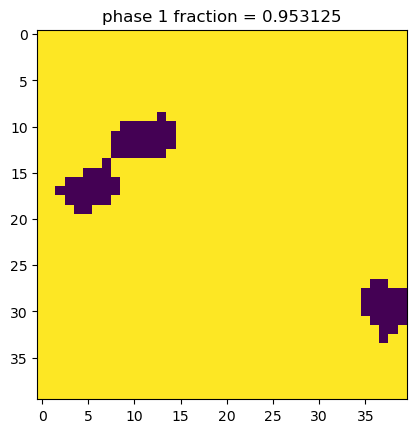

In [ ]:
# Basic domain and grain size parameters
domain_size = 2000 # square domain size
num_grain_vertically = 7
num_grain_horizontally = 7

mesh_size = 50
domain_center_x = 0
domain_center_y = 0

# Prepare file names
filename_base = f"../EBSD_files/Polycrystal_Domain_{domain_size}_NumGrainHor_{num_grain_horizontally}_NumGrainVert_{num_grain_vertically}"


# expected_fraction = [0.25, 0.75]
expected_fraction = [0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95]
threshold_fraction = 0.01
phase_fraction = 0

for i in range(len(expected_fraction)):
    while abs(phase_fraction - expected_fraction[i]) > threshold_fraction:
        [num_grains_actual_final, domain_min_x, domain_max_x, x_step, position_x_final, domain_min_y, domain_max_y, y_step, position_y_final, grain_structure_final, phase_index, phase_fraction, phase_outline] = \
            create_voronoi_polycrystal(domain_size, mesh_size, num_grain_vertically, num_grain_horizontally, expected_fraction[i])

        print(f">>>> phase 1 fraction = {phase_fraction}")

    # ================================ plot figure =============================== #
    ratio_elongation = num_grain_vertically/num_grain_horizontally
    grain_structure_final_copy = np.copy(grain_structure_final)
    grain_structure_final_copy.resize(int(domain_size / mesh_size),int(domain_size / mesh_size * ratio_elongation))
    poly_outline = np.flipud(grain_structure_final_copy)
    dpi_value = 100
    # Save grain figures for simulations with exact resolution
    fig = plt.figure(figsize=(poly_outline.shape[1]/dpi_value, poly_outline.shape[0]/dpi_value), dpi=dpi_value)
    ax = fig.add_axes([0,0,1,1])
    plt.imshow(poly_outline)
    plt.axis("off")
    plt.savefig(f"{filename_base}_PF0{int(expected_fraction[i]*100)}_microstructure.png", bbox_inches='tight', pad_inches=0, dpi=dpi_value)
    plt.close()

    phase_outline = np.zeros(poly_outline.shape)
    for index, phase_ind in enumerate(phase_index):
        phase_outline += (phase_ind == 1) * (poly_outline == index)
    # Save phase figures for simulations with exact resolution
    fig = plt.figure(figsize=(phase_outline.shape[1]/dpi_value, phase_outline.shape[0]/dpi_value), dpi=dpi_value)
    ax = fig.add_axes([0,0,1,1])
    plt.imshow(phase_outline)
    plt.axis("off")
    phase_fraction = np.sum(phase_outline == 1) / np.sum(phase_outline != -1)
    plt.title(f"phase 1 fraction = {phase_fraction}")
    plt.savefig(f"{filename_base}_PF0{int(expected_fraction[i]*100)}_phase_structure.png", bbox_inches='tight', pad_inches=0, dpi=dpi_value)
    plt.close()

    # ================================= save EBSD ================================ #

    angle_deg_3params = np.zeros((num_grains_actual_final, 3))
    angle_deg_3params[:,0] = np.random.uniform(0, 2*np.pi, num_grains_actual_final)
    angle_deg_3params[:,1] = np.random.uniform(0, np.pi, num_grains_actual_final)
    angle_deg_3params[:,2] = np.random.uniform(0, 2*np.pi, num_grains_actual_final)

    filename_EBSD = f"{filename_base}_PF0{int(expected_fraction[i]*100)}.txt"
    fileEBSD = open(filename_EBSD,"w")
    L = ['# Header:    Marmot Input File \n',
        '# Date:      24-May-2021 00:23:55\n',
        '# \n',
        '# Column 1:  Euler angle "phi1" (in radians)\n',
        '# Column 2:  Euler angle "PHI" (in radians)\n',
        '# Column 3:  Euler angle "phi2" (in radians)\n',
        '# Column 4:  x-coordinate (in nm)\n',
        '# Column 5:  y-coordinate (in nm)\n',
        '# Column 6:  z-coordinate (in nm)\n',
        '# Column 7:  grain number (integer)\n',
        '# Column 8:  phase number (integer)\n',
        '# Column 9:  symmetry class (from TSL)\n',
        '#\n',
        '# Phase 1:   Li2O (symmetry class = 225)\n',
        f'# Number of Grains in Phase 1:  {num_grains_actual_final}\n',
        '#\n',
        f'# X_Min:      {domain_min_x}\n',
        f'# X_Max:      {domain_max_x}\n',
        f'# X_step:     {x_step}\n',
        f'# X_Dim:      {len(np.unique(position_x_final))}\n',
        '#\n',
        f'# Y_Min:      {domain_min_y}\n',
        f'# Y_Max:      {domain_max_y}\n',
        f'# Y_step:     {y_step}\n',
        f'# Y_Dim:      {len(np.unique(position_y_final))}\n',
        '#\n',
        '# Z_Min:      0.000000\n',
        '# Z_Max:      0.000000\n',
        '# Z_step:     0.000000\n',
        '# Z_Dim:      0\n',
        '#\n']
    fileEBSD.writelines(L)

    for i in range(len(position_x_final)):
        L = f"{angle_deg_3params[int(grain_structure_final[i]),0]:.5f} "\
            f"{angle_deg_3params[int(grain_structure_final[i]),1]:.5f} "\
            f"{angle_deg_3params[int(grain_structure_final[i]),2]:.5f} "\
            f"{position_x_final[i]:.5f} {position_y_final[i]:.5f} "\
            f"0.00000 {int(grain_structure_final[i]):>3} {phase_index[int(grain_structure_final[i])]} {225} \n"
        fileEBSD.write(L)

    fileEBSD.close()



## Initialize Input parameters: small grains ready for AEH model directly
Output with png type of simulation data

In [12]:
# Basic domain and grain size parameters
domain_size = 2048  # domain size from long edge of BES
num_grain_vertically = 800
num_grain_horizontally = 800
n_jobs=12

mesh_size = 1
domain_center_x = 0
domain_center_y = 0

# Prepare file names
if not os.path.exists("../simulation_IC_files/"): os.mkdir("../simulation_IC_files/")
filename_base = f"../simulation_IC_files/Polycrystal_Domain_{domain_size}_NumGrainHor_{num_grain_horizontally}_NumGrainVert_{num_grain_vertically}"


# expected_fraction = [0.25, 0.75]
expected_fraction = [0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95]
threshold_fraction = 0.01
phase_fraction = 0

for i in range(len(expected_fraction)):
    while abs(phase_fraction - expected_fraction[i]) > threshold_fraction:
        [num_grains_actual_final, domain_min_x, domain_max_x, x_step, position_x_final, domain_min_y, domain_max_y, y_step, position_y_final, grain_structure_final, phase_index, phase_fraction, phase_outline] = \
            create_voronoi_polycrystal(domain_size, mesh_size, num_grain_vertically, num_grain_horizontally, expected_fraction[i], n_jobs=n_jobs)

        print(f">>>> phase 1 fraction = {phase_fraction}")

    # ================================ plot figure =============================== #
    ratio_elongation = num_grain_vertically/num_grain_horizontally
    grain_structure_final.resize(int(domain_size / mesh_size),int(domain_size / mesh_size * ratio_elongation))
    poly_outline = np.flipud(grain_structure_final)
    phase_outline.resize(int(domain_size / mesh_size),int(domain_size / mesh_size * ratio_elongation))
    phase_outline = np.flipud(phase_outline)
    dpi_value = 100
    # Save grain figures for simulations with exact resolution
    fig = plt.figure(figsize=(poly_outline.shape[1]/dpi_value, poly_outline.shape[0]/dpi_value), dpi=dpi_value)
    ax = fig.add_axes([0,0,1,1])
    plt.imshow(poly_outline, cmap='gray', interpolation='none')
    plt.axis("off")
    plt.savefig(f"{filename_base}_PF0{int(expected_fraction[i]*100)}_microstructure.png", bbox_inches='tight', pad_inches=0, dpi=dpi_value)
    plt.close()

    fig = plt.figure(figsize=(phase_outline.shape[1]/dpi_value, phase_outline.shape[0]/dpi_value), dpi=dpi_value)
    ax = fig.add_axes([0,0,1,1])
    plt.imshow(phase_outline, cmap='gray', interpolation='none')
    plt.axis("off")
    # phase_fraction = np.sum(phase_outline == 1) / np.sum(phase_outline != -1)
    # plt.title(f"phase 1 fraction = {phase_fraction}")
    plt.savefig(f"{filename_base}_PF0{int(expected_fraction[i]*100)}_phase_structure.png", bbox_inches='tight', pad_inches=0, dpi=dpi_value)
    plt.close()



The number of centroids is equal to:  640000
The original number of unique grains was equal to: 640000
The number of unique grains is equal to: 639988
test: All is good with mesh size and steps in x and y directions
Completed the fraction calculation
>>>> phase 1 fraction = 0.050042152404785156
The number of centroids is equal to:  640000
The original number of unique grains was equal to: 640000
The number of unique grains is equal to: 639979
test: All is good with mesh size and steps in x and y directions
Completed the fraction calculation
>>>> phase 1 fraction = 0.15021729469299316
The number of centroids is equal to:  640000
The original number of unique grains was equal to: 640000
The number of unique grains is equal to: 639986
test: All is good with mesh size and steps in x and y directions
Completed the fraction calculation
>>>> phase 1 fraction = 0.250049352645874
The number of centroids is equal to:  640000
The original number of unique grains was equal to: 640000
The number of